In [3]:
%pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# ARMA pour la modélisation des matchs nba 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import re

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from nba_api.stats.endpoints import teamgamelog, playbyplayv3
from nba_api.stats.static import teams

print("✅ Imports OK")


✅ Imports OK


In [5]:
# ================================================================
# PARAMÈTRES
# ================================================================
TEAM_NAME = "Los Angeles Lakers"
SEASON    = "2024-25"
N_GAMES   = 30       # nombre de matchs à récupérer
SLEEP     = 1.2      # délai entre requêtes (rate limiting)

# ================================================================
# FONCTIONS UTILITAIRES
# ================================================================
def nba_request_with_retry(endpoint_cls, max_retries=4, backoff=3.0, **kwargs):
    delay = backoff
    for attempt in range(1, max_retries + 1):
        try:
            return endpoint_cls(timeout=60, **kwargs)
        except Exception as e:
            if attempt == max_retries:
                raise
            print(f"  ⚠️  Tentative {attempt}/{max_retries} échouée. Retry dans {delay:.0f}s…")
            time.sleep(delay)
            delay *= 2

print("✅ Paramètres et fonctions prêts")


✅ Paramètres et fonctions prêts


In [6]:
# ================================================================
# ÉTAPE 1 : Récupérer le game log de la saison
# ================================================================
team_info = teams.find_teams_by_full_name(TEAM_NAME)[0]
TEAM_ID   = team_info["id"]
print(f"Équipe : {TEAM_NAME} (ID={TEAM_ID})")

gamelog = nba_request_with_retry(
    teamgamelog.TeamGameLog,
    team_id=TEAM_ID,
    season=SEASON,
    season_type_all_star="Regular Season",
)
time.sleep(SLEEP)

df_games = gamelog.get_data_frames()[0]
game_ids = df_games["Game_ID"].iloc[:N_GAMES].tolist()
print(f"Matchs disponibles : {len(df_games)}  —  on en prend {N_GAMES}")
df_games[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS"]].head(5)


Équipe : Los Angeles Lakers (ID=1610612747)
Matchs disponibles : 82  —  on en prend 30
Matchs disponibles : 82  —  on en prend 30


,Game_ID,GAME_DATE,MATCHUP,WL,PTS
0,0022401199,"APR 13, 2025",LAL @ POR,L,81
1,0022401185,"APR 11, 2025",LAL vs. HOU,W,140
2,0022401159,"APR 09, 2025",LAL @ DAL,W,112
3,0022401153,"APR 08, 2025",LAL @ OKC,L,120
4,0022401135,"APR 06, 2025",LAL @ OKC,W,126


In [7]:
# ================================================================
# ÉTAPE 2 : Récupérer le play-by-play et calculer le différentiel final
# ================================================================
def fetch_score_differential(game_ids, team_matchups, sleep=SLEEP):
    """
    Pour chaque match, calcule le différentiel de score FINAL
    du point de vue de l'équipe cible (+ si victoire, - si défaite).
    """
    records = []
    for i, gid in enumerate(game_ids):
        gid_str = str(gid).zfill(10)
        try:
            pbp = nba_request_with_retry(
                playbyplayv3.PlayByPlayV3, game_id=gid_str
            ).get_data_frames()[0]

            pbp["SCORE_HOME"]    = pd.to_numeric(pbp["scoreHome"], errors="coerce").ffill().fillna(0)
            pbp["SCORE_VISITOR"] = pd.to_numeric(pbp["scoreAway"],  errors="coerce").ffill().fillna(0)
            pbp["SCOREMARGIN"]   = pbp["SCORE_HOME"] - pbp["SCORE_VISITOR"]

            # +1 si notre équipe était HOME, -1 si VISITOR
            matchup = team_matchups[team_matchups["Game_ID"] == gid]["MATCHUP"].values[0]
            sign = 1 if "vs." in matchup else -1

            final_margin = pbp["SCOREMARGIN"].iloc[-1] * sign
            records.append({"game_id": gid, "score_differential": final_margin})
            print(f"  ✅ [{i+1}/{len(game_ids)}] {matchup}  →  différentiel={final_margin:+.0f}")
        except Exception as e:
            print(f"  ❌ [{i+1}/{len(game_ids)}] Game {gid_str} abandonné : {e}")
        time.sleep(sleep)

    return pd.DataFrame(records).set_index("game_id")

print(f"Récupération du différentiel sur {N_GAMES} matchs… (~{N_GAMES * SLEEP:.0f}s)")
df_nba = fetch_score_differential(game_ids, df_games)
print(f"\n✅ df_nba construit : {len(df_nba)} matchs")
df_nba.head(10)


Récupération du différentiel sur 30 matchs… (~36s)
  ✅ [1/30] LAL @ POR  →  différentiel=-28
  ✅ [1/30] LAL @ POR  →  différentiel=-28
  ✅ [2/30] LAL vs. HOU  →  différentiel=+31
  ✅ [2/30] LAL vs. HOU  →  différentiel=+31
  ✅ [3/30] LAL @ DAL  →  différentiel=+15
  ✅ [3/30] LAL @ DAL  →  différentiel=+15
  ✅ [4/30] LAL @ OKC  →  différentiel=-16
  ✅ [4/30] LAL @ OKC  →  différentiel=-16
  ✅ [5/30] LAL @ OKC  →  différentiel=+27
  ✅ [5/30] LAL @ OKC  →  différentiel=+27
  ✅ [6/30] LAL vs. NOP  →  différentiel=+16
  ✅ [6/30] LAL vs. NOP  →  différentiel=+16
  ✅ [7/30] LAL vs. GSW  →  différentiel=-7
  ✅ [7/30] LAL vs. GSW  →  différentiel=-7
  ✅ [8/30] LAL vs. HOU  →  différentiel=+6
  ✅ [8/30] LAL vs. HOU  →  différentiel=+6
  ✅ [9/30] LAL @ MEM  →  différentiel=+7
  ✅ [9/30] LAL @ MEM  →  différentiel=+7
  ✅ [10/30] LAL @ CHI  →  différentiel=-2
  ✅ [10/30] LAL @ CHI  →  différentiel=-2
  ✅ [11/30] LAL @ IND  →  différentiel=+1
  ✅ [11/30] LAL @ IND  →  différentiel=+1
  ✅ [12/30] LAL

,score_differential
game_id,
0022401199,-28.0
0022401185,31.0
0022401159,15.0
0022401153,-16.0
0022401135,27.0
0022401126,16.0
0022401117,-7.0
0022401096,6.0
0022401078,7.0


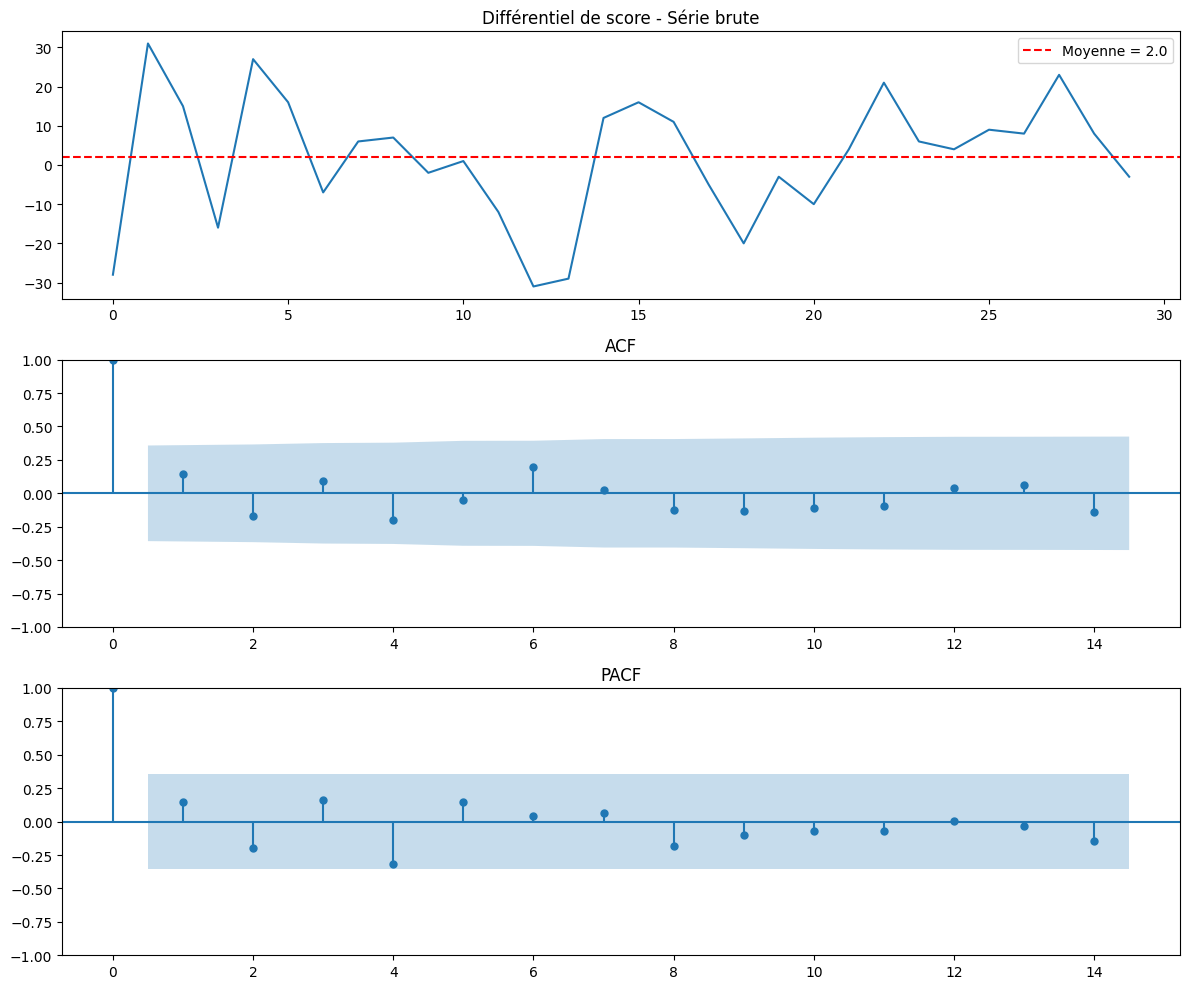

ℹ️  30 observations → lags utilisés : 14


In [9]:
# ================================================================
# ÉTAPE 3 : Visualisation de la série brute + ACF/PACF
# ================================================================
serie = df_nba['score_differential']

# Nombre de lags : max 50% de la taille de la série (contrainte PACF)
max_lags = len(serie) // 2 - 1

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(serie.values)
axes[0].set_title('Différentiel de score - Série brute')
axes[0].axhline(y=serie.mean(), color='r', linestyle='--', label=f'Moyenne = {serie.mean():.1f}')
axes[0].legend()

plot_acf(serie, lags=max_lags, ax=axes[1], title='ACF')
plot_pacf(serie, lags=max_lags, ax=axes[2], title='PACF')
plt.tight_layout()
plt.show()

print(f"ℹ️  {len(serie)} observations → lags utilisés : {max_lags}")


In [11]:
# ================================================================
# ÉTAPE 4 : Test ADF (Augmented Dickey-Fuller)
# ================================================================
def test_adf(serie, nom="Série"):
    specs = {
        'Sans constante'       : 'n',   # 'nc' → 'n' depuis statsmodels >= 0.14
        'Avec constante'       : 'c',
        'Constante + tendance' : 'ct'
    }
    print(f"\n{'='*55}")
    print(f"  TEST ADF — {nom}")
    print(f"{'='*55}")
    for label, regression in specs.items():
        result = adfuller(serie, regression=regression, autolag='AIC')
        t_stat, p_value, n_lags, n_obs = result[0], result[1], result[2], result[3]
        cv_1, cv_5, cv_10 = result[4]['1%'], result[4]['5%'], result[4]['10%']
        conclusion = "STATIONNAIRE ✅" if p_value < 0.05 else "NON STATIONNAIRE ❌"
        print(f"\n  Spécification : {label}")
        print(f"  Lags retenus  : {n_lags}  |  Observations : {n_obs}")
        print(f"  t-statistique : {t_stat:.4f}")
        print(f"  p-value       : {p_value:.4f}")
        print(f"  Valeurs critiques : 1%={cv_1:.3f} | 5%={cv_5:.3f} | 10%={cv_10:.3f}")
        print(f"  → Conclusion  : {conclusion}")

test_adf(serie, nom="Différentiel de score NBA")



  TEST ADF — Différentiel de score NBA

  Spécification : Sans constante
  Lags retenus  : 1  |  Observations : 28
  t-statistique : -4.1126
  p-value       : 0.0000
  Valeurs critiques : 1%=-2.650 | 5%=-1.953 | 10%=-1.610
  → Conclusion  : STATIONNAIRE ✅

  Spécification : Avec constante
  Lags retenus  : 1  |  Observations : 28
  t-statistique : -4.0661
  p-value       : 0.0011
  Valeurs critiques : 1%=-3.689 | 5%=-2.972 | 10%=-2.625
  → Conclusion  : STATIONNAIRE ✅

  Spécification : Constante + tendance
  Lags retenus  : 3  |  Observations : 26
  t-statistique : -3.2043
  p-value       : 0.0835
  Valeurs critiques : 1%=-4.357 | 5%=-3.595 | 10%=-3.234
  → Conclusion  : NON STATIONNAIRE ❌


In [12]:
# ================================================================
# ÉTAPE 5 : Test KPSS (complémentaire au test ADF)
# ================================================================
def test_kpss(serie, nom="Série"):
    print(f"\n{'='*55}")
    print(f"  TEST KPSS — {nom}")
    print(f"{'='*55}")
    for regression in ['c', 'ct']:
        stat, p_value, lags, crit = kpss(serie, regression=regression, nlags='auto')
        label = 'Avec constante' if regression == 'c' else 'Constante + tendance'
        conclusion = "NON STATIONNAIRE ❌" if p_value < 0.05 else "STATIONNAIRE ✅"
        print(f"\n  Spécification : {label}")
        print(f"  Statistique   : {stat:.4f}")
        print(f"  p-value       : {p_value:.4f}")
        print(f"  → Conclusion  : {conclusion}")

test_kpss(serie, nom="Différentiel de score NBA")



  TEST KPSS — Différentiel de score NBA

  Spécification : Avec constante
  Statistique   : 0.1181
  p-value       : 0.1000
  → Conclusion  : STATIONNAIRE ✅

  Spécification : Constante + tendance
  Statistique   : 0.1054
  p-value       : 0.1000
  → Conclusion  : STATIONNAIRE ✅


/var/folders/22/4167hzhn4jq9dwqcl0907g5w0000gn/T/ipykernel_39641/3790901943.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(serie, regression=regression, nlags='auto')
/var/folders/22/4167hzhn4jq9dwqcl0907g5w0000gn/T/ipykernel_39641/3790901943.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(serie, regression=regression, nlags='auto')


In [13]:
# ================================================================
# ÉTAPE 6 : Différenciation si non stationnaire
# ================================================================
def stationnariser(serie, nom="Série"):
    """Différencie jusqu'à obtenir la stationnarité (test ADF)."""
    d = 0
    s = serie.copy()
    while True:
        result  = adfuller(s.dropna(), regression='c', autolag='AIC')
        p_value = result[1]
        if p_value < 0.05:
            print(f"\n✅ Série stationnaire après d={d} différenciation(s)")
            return s, d
        else:
            print(f"  d={d} : p-value={p_value:.4f} → non stationnaire, on différencie")
            s = s.diff()
            d += 1
        if d > 3:
            print("⚠️ Ordre de différenciation > 3, vérifier la série")
            break
    return s, d

serie_stat, d = stationnariser(serie, nom="Différentiel de score NBA")



✅ Série stationnaire après d=0 différenciation(s)


## Interprétation des résultats — Lakers 2024-25 (30 matchs)

### Test ADF

| Spécification | t-stat | p-value | Conclusion |
|---|---|---|---|
| Sans constante | -4.11 | 0.000 | STATIONNAIRE ✅ |
| Avec constante | -4.07 | 0.001 | STATIONNAIRE ✅ |
| Constante + tendance | -3.20 | 0.084 | NON STATIONNAIRE ❌ |

La spécification **"Constante + tendance"** ne rejette pas H₀, mais c'est la plus restrictive et la moins pertinente ici : un différentiel de score n'a pas de raison d'avoir une **tendance déterministe** sur une saison. Les deux spécifications économiquement pertinentes ("sans constante" et "avec constante") concluent à la **stationnarité**.

### Test KPSS

| Spécification | Statistique | p-value | Conclusion |
|---|---|---|---|
| Avec constante | 0.118 | ≥ 0.10 | STATIONNAIRE ✅ |
| Constante + tendance | 0.105 | ≥ 0.10 | STATIONNAIRE ✅ |

> ⚠️ Le warning `InterpolationWarning` indique que la statistique est **en dehors de la table de valeurs critiques**, ce qui signifie que la p-value réelle est **encore plus grande que 0.10** → conclusion de stationnarité encore plus forte.

### Conclusion générale

**ADF rejette H₀ + KPSS ne rejette pas H₀ → Série stationnaire (Cas 1)**

$$X_t \sim \text{ARMA}(p, q) \quad \text{(pas de différenciation nécessaire, } d = 0\text{)}$$

**Interprétation NBA :** Le différentiel de score des Lakers oscille autour d'une **moyenne stable** au fil des matchs. Les chocs (grandes victoires ou défaites) sont **temporaires et se résorbent** — c'est cohérent avec l'hypothèse que le momentum existe à court terme mais ne persiste pas sur plusieurs matchs. On peut donc ajuster un **ARMA(p, q)** directement sur la série brute.

### Prochaine étape : sélection des ordres p et q

Lire l'ACF et la PACF :
- **ACF** coupe après le lag $q$ → ordre MA
- **PACF** coupe après le lag $p$ → ordre AR
- Confirmer avec les critères **AIC / BIC**
